**图像基础与数据处理**：用 OpenCV 和 PyTorch 处理图像数据

导入依赖库

In [9]:
%matplotlib inline
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
# 解决中文显示问题：指定系统自带的微软雅黑字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
# 解决坐标轴负号显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

读取图像与基础属性

In [5]:
# 读取图像（路径加r前缀，修复转义警告）
img_bgr = cv2.imread(r"E:\home study\week2\sample.jpg")
# BGR转RGB，适配matplotlib显示
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 打印图像基础属性
print(f"图像尺寸: {img_rgb.shape}  格式：(高度H, 宽度W, 通道数C)")
print(f"像素值范围: [{img_rgb.min()}, {img_rgb.max()}]  正常彩色图范围为0~255")

图像尺寸: (810, 1440, 3)  格式：(高度H, 宽度W, 通道数C)
像素值范围: [18, 255]  正常彩色图范围为0~255


可视化原图与图像对比

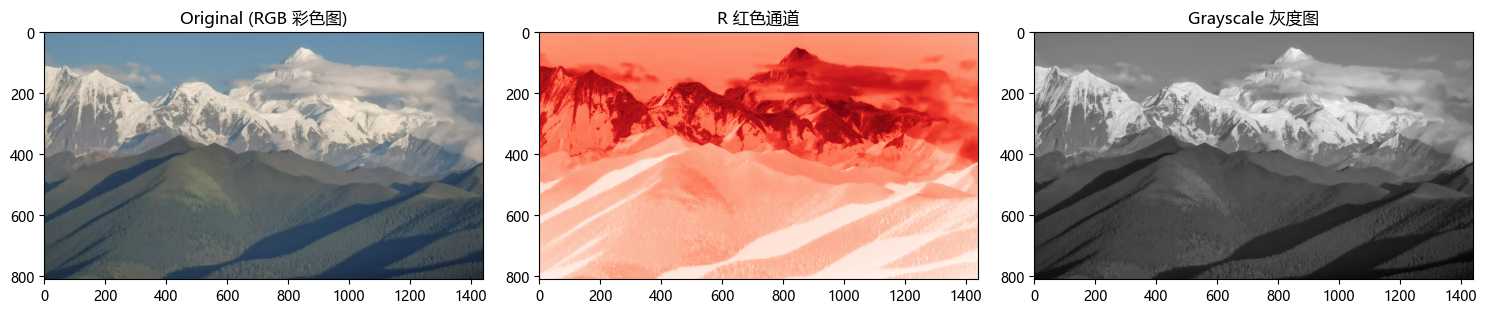

In [11]:
# 创建1行3列的子图画布
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 第1张：原始RGB彩色图
axes[0].imshow(img_rgb)
axes[0].set_title('Original (RGB 彩色图)')

# 第2张：单独红色通道
axes[1].imshow(img_rgb[:,:,0], cmap='Reds')
axes[1].set_title('R 红色通道')

# 第3张：灰度图（3通道降为1通道）
axes[2].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY), cmap='gray')
axes[2].set_title('Grayscale 灰度图')

plt.tight_layout()
plt.show()

深度学习常用图像变换，实现 CV 模型训练最核心的 4 类预处理操作，打印变换后的维度 / 范围，验证变换效果。

In [17]:
# 1. 尺寸缩放
resized_fixed = cv2.resize(img_bgr, (224, 224))  # 固定尺寸缩放到224×224（适配模型输入）
resized_ratio = cv2.resize(
    img_bgr,
    (int(img_bgr.shape[1] * 0.5), int(img_bgr.shape[0] * 0.5))
)  # 等比例缩小50%，不改变图像长宽比

# 2. 像素归一化：0~255整数 → 0~1浮点数（模型训练必做）
img_float = img_rgb.astype(np.float32) / 255.0

# 3. ImageNet标准化：对齐预训练模型的数据分布（迁移学习必做）
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
img_normalized = (img_float - mean) / std

# 4. 颜色空间转换
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)  # 转灰度图，降维减少计算量
hsv  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)   # 转HSV空间，适合颜色分割

# 打印变换结果验证
print(f"固定缩放后尺寸：{resized_fixed.shape}")
print(f"等比例缩放后尺寸：{resized_ratio.shape}")
print(f"归一化后像素范围：[{img_float.min():.2f}, {img_float.max():.2f}]")
print(f"灰度图维度：{gray.shape}（单通道，无第三维）")

固定缩放后尺寸：(224, 224, 3)
等比例缩放后尺寸：(405, 720, 3)
归一化后像素范围：[0.07, 1.00]
灰度图维度：(810, 1440)（单通道，无第三维）


边缘与梯度特征提取
通过高斯模糊去噪，再用 Canny、Sobel 算子提取图像的边缘 / 梯度特征，理解传统计算机视觉的底层特征提取逻辑。

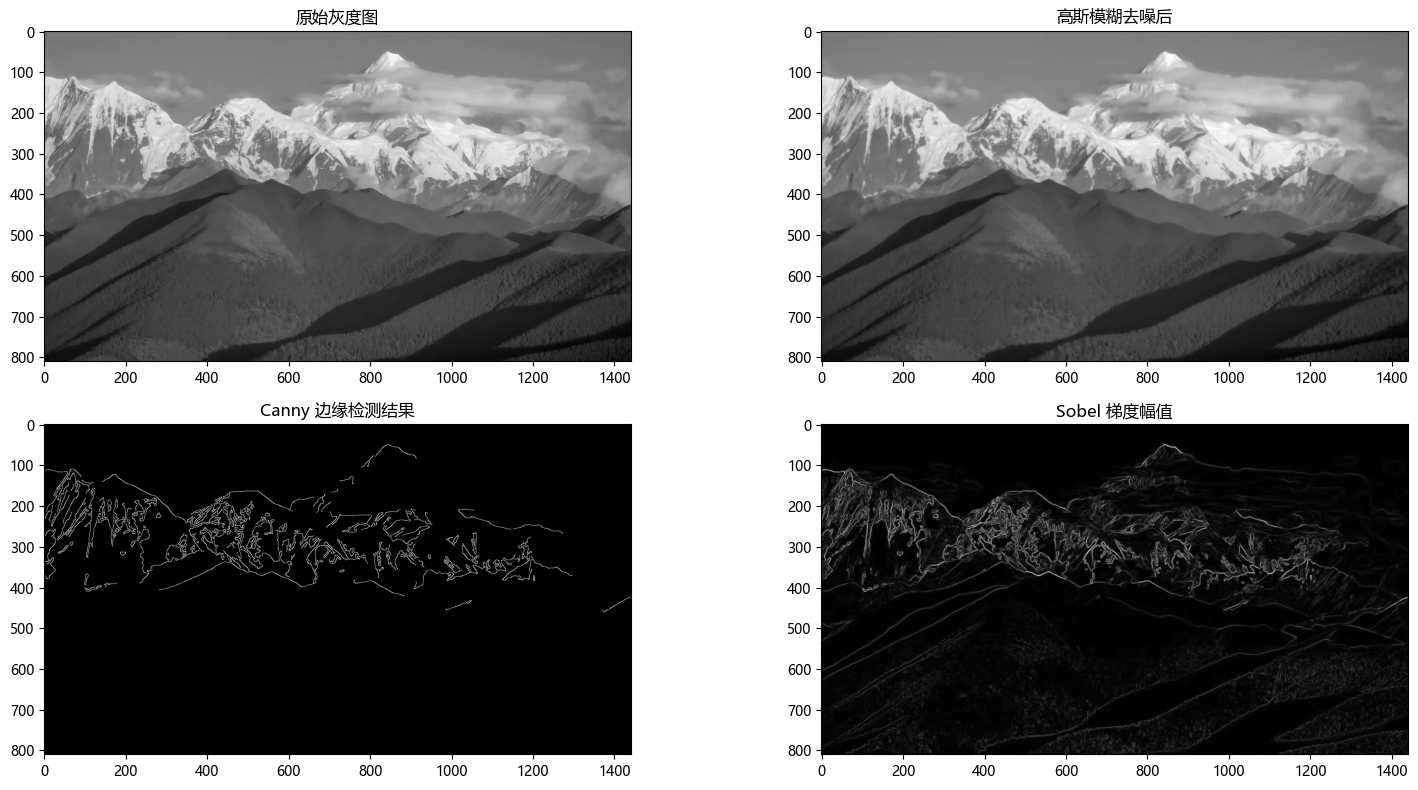

In [20]:
# 1. 高斯模糊：平滑去噪，减少边缘检测的噪点干扰
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# 2. Canny边缘检测：提取图像清晰的轮廓边缘
edges_canny = cv2.Canny(blurred, threshold1=50, threshold2=150)

# 3. Sobel梯度算子：分别计算水平、垂直方向的灰度变化幅度
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)  # 水平梯度
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)  # 垂直梯度
gradient_mag = np.sqrt(sobelx**2 + sobely**2)        # 合成梯度幅值

# 可视化对比
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes[0,0].imshow(gray, cmap='gray')
axes[0,0].set_title('原始灰度图')
axes[0,1].imshow(blurred, cmap='gray')
axes[0,1].set_title('高斯模糊去噪后')
axes[1,0].imshow(edges_canny, cmap='gray')
axes[1,0].set_title('Canny 边缘检测结果')
axes[1,1].imshow(gradient_mag, cmap='gray')
axes[1,1].set_title('Sobel 梯度幅值')
plt.tight_layout()
plt.show()

绘制并保存颜色直方图
统计 RGB 三个通道的像素值分布，绘制颜色直方图，分析图像的明暗、色彩偏向；同时导出为 PDF 矢量图，可用于报告。

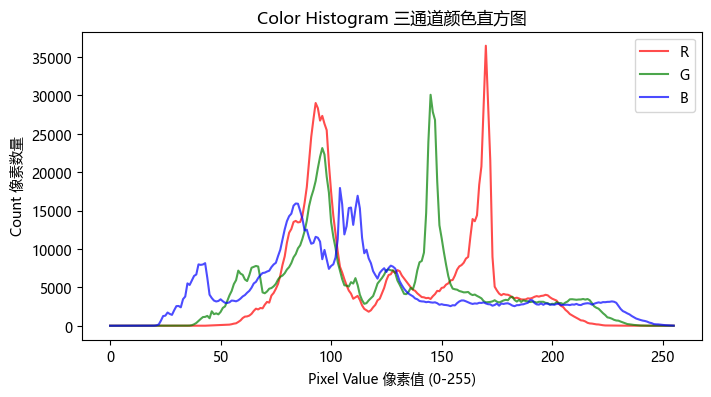

In [23]:
# 创建画布
fig, ax = plt.subplots(figsize=(8, 4))
colors = ('r', 'g', 'b')

# 循环统计三个通道的像素直方图
for i, color in enumerate(colors):
    hist = cv2.calcHist([img_bgr], [i], None, [256], [0, 256])
    ax.plot(hist.flatten(), color=color, alpha=0.7, label=color.upper())

# 图表样式设置
ax.set_xlabel('Pixel Value 像素值 (0-255)')
ax.set_ylabel('Count 像素数量')
ax.set_title('Color Histogram 三通道颜色直方图')
ax.legend()

# 先保存图片，再显示（顺序不能反）
plt.savefig('histogram.pdf', bbox_inches='tight')
plt.show()

完整代码

<>:8: SyntaxWarning: invalid escape sequence '\h'
<>:8: SyntaxWarning: invalid escape sequence '\h'
C:\Windows\Temp\ipykernel_33204\1316024279.py:8: SyntaxWarning: invalid escape sequence '\h'
  img_bgr = cv2.imread("E:\home study\week2\sample.jpg")              # BGR 格式（OpenCV 默认）


图像尺寸: (810, 1440, 3)
像素值范围: [18, 255]


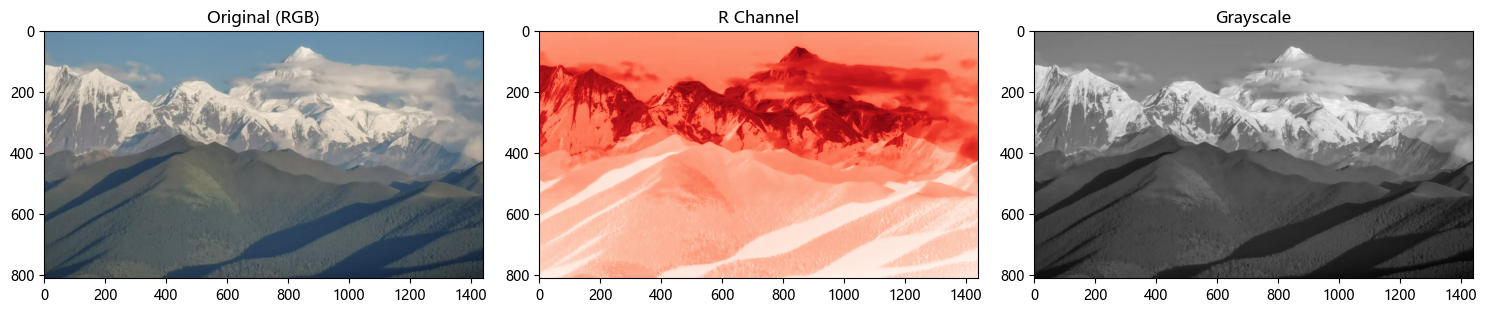

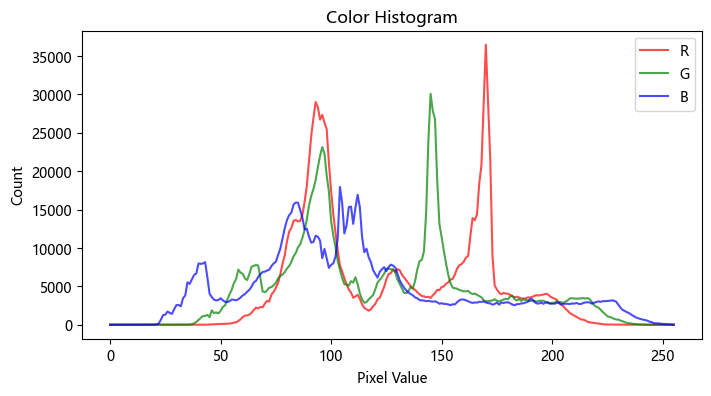

In [14]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
%matplotlib inline

# ── 图像读取与基础属性 ────────────────────────────────
img_bgr = cv2.imread("E:\home study\week2\sample.jpg")              # BGR 格式（OpenCV 默认）
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)  # 转 RGB 用于 matplotlib
print(f"图像尺寸: {img_rgb.shape}")             # (H, W, C)
print(f"像素值范围: [{img_rgb.min()}, {img_rgb.max()}]")

# ── 显示图像（Notebook 中）────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_rgb)
axes[0].set_title('Original (RGB)')
axes[1].imshow(img_rgb[:,:,0], cmap='Reds')
axes[1].set_title('R Channel')
axes[2].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY), cmap='gray')
axes[2].set_title('Grayscale')
plt.tight_layout(); plt.show()

# ── 常用图像变换 ──────────────────────────────────────
# 缩放
resized = cv2.resize(img_bgr, (224, 224))
resized_keep = cv2.resize(
    img_bgr,
    (int(img_bgr.shape[1] * 0.5), int(img_bgr.shape[0] * 0.5))
)

# 归一化（0-255 → 0-1，训练必须做）
img_float = img_rgb.astype(np.float32) / 255.0
# ImageNet 标准化
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
img_normalized = (img_float - mean) / std

# 颜色空间转换
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
hsv  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# ── 边缘检测（理解图像特征）────────────────────────────
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
edges_canny = cv2.Canny(blurred, threshold1=50, threshold2=150)

# Sobel 梯度
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
gradient_mag = np.sqrt(sobelx**2 + sobely**2)

# ── 像素直方图 ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
colors = ('r', 'g', 'b')
for i, color in enumerate(colors):
    hist = cv2.calcHist([img_bgr], [i], None, [256], [0, 256])
    ax.plot(hist.flatten(), color=color, alpha=0.7, label=color.upper())
ax.set_xlabel('Pixel Value'), ax.set_ylabel('Count')
ax.set_title('Color Histogram')
ax.legend(); plt.savefig('histogram.pdf', bbox_inches='tight'); plt.show()

这段代码是OpenCV 图像处理入门级完整模板，覆盖了计算机视觉任务中最基础的「图像读取 - 格式转换 - 空间变换 - 特征提取 - 统计可视化」全流程，常用于图像数据探查、深度学习预处理前置校验、CV 基础功能学习。

**注**：
OpenCV 默认读取的彩色图是 BGR 通道顺序，而 matplotlib、PIL、绝大多数深度学习框架都用 RGB 顺序
